In [1]:
import pandas as pd
import numpy as num_paths
import matplotlib.pyplot as psnrResault
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from matplotlib import pyplot as plt

import pickle

/home/gurhancoban/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:62: UserWarning: Pandas requires version '1.3.4' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
df=pd.read_csv("data09102024.csv")

In [3]:
df=pd.DataFrame(df)
df.head()

,host,avgRTT,packetLoss,latency,hopCount,bandwidth,psnr,ssim_first,ssim_second,kaynak,...,kayip,kayip_orani,h10gelen,h10giden,h10toplam,h14gelen,h14giden,h14toplam,type,server
0,h13,204.792,0.0,31,2,10000000,36.507699,0.996039,24.022245,67209812,...,-161196,0.000000,4776,39462,44238.0,5072.0,39251.0,44323.0,3.0,h10
1,h1,336.581,0.0,78,3,10000000,35.079593,0.994246,22.400471,67209812,...,-161196,0.000000,962710,44650,1051598.0,5072.0,40267.0,89662.0,3.0,h14
2,h2,260.959,0.0,72,3,10000000,36.081554,0.994275,22.422055,67209812,...,100948,0.390038,3095346,57173,4204117.0,983906.0,47582.0,1121150.0,3.0,h14
3,h3,239.227,0.0,52,2,10000000,29.715019,0.982092,17.469591,67209812,...,1149524,1.950191,5181362,67595,9453074.0,4075282.0,62326.0,5258758.0,3.0,h14
4,h4,409.193,0.0,81,3,10000000,35.194807,0.993585,21.927812,67209812,...,100948,0.390038,7274784,84244,16812102.0,9233590.0,87819.0,14580167.0,3.0,h10


In [4]:
df["mos"]=6
df.shape[0]
for i in range(0,df.shape[0],1):
    if df.ssim_first[i]>=0.99:
        df.mos[i]=5
    elif df.ssim_first[i]>=0.95 and df.ssim_first[i]<0.99:
        df.mos[i]=4
    elif df.ssim_first[i]>=0.88 and df.ssim_first[i]<0.95:
        df.mos[i]=3
    elif df.ssim_first[i]>=0.5 and df.ssim_first[i]<0.88:
        df.mos[i]=2
    elif df.ssim_first[i]<0.5:
        df.mos[i]=1

df

,host,avgRTT,packetLoss,latency,hopCount,bandwidth,psnr,ssim_first,ssim_second,kaynak,...,kayip_orani,h10gelen,h10giden,h10toplam,h14gelen,h14giden,h14toplam,type,server,mos
0,h13,204.792,0.0,31,2,10000000,36.507699,0.996039,24.022245,67209812,...,0.000000,4776,39462,4.423800e+04,5072.0,39251.0,4.432300e+04,3.0,h10,5
1,h1,336.581,0.0,78,3,10000000,35.079593,0.994246,22.400471,67209812,...,0.000000,962710,44650,1.051598e+06,5072.0,40267.0,8.966200e+04,3.0,h14,5
2,h2,260.959,0.0,72,3,10000000,36.081554,0.994275,22.422055,67209812,...,0.390038,3095346,57173,4.204117e+06,983906.0,47582.0,1.121150e+06,3.0,h14,5
3,h3,239.227,0.0,52,2,10000000,29.715019,0.982092,17.469591,67209812,...,1.950191,5181362,67595,9.453074e+06,4075282.0,62326.0,5.258758e+06,3.0,h14,4
4,h4,409.193,0.0,81,3,10000000,35.194807,0.993585,21.927812,67209812,...,0.390038,7274784,84244,1.681210e+07,9233590.0,87819.0,1.458017e+07,3.0,h10,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
588,h2,313.056,0.0,93,4,10000000,15.997397,0.743165,5.903466,67209812,...,35.103446,145148612,1511787,9.567170e+08,153118830.0,1597934.0,9.246500e+08,3.0,h10,2
589,h3,308.388,0.0,86,4,10000000,16.057587,0.733531,5.743539,67209812,...,37.833714,160788080,1632081,1.119137e+09,172640846.0,1740744.0,1.099032e+09,3.0,h10,2
590,h4,261.973,0.0,65,3,10000000,15.955686,0.722000,5.559557,67209812,...,41.734097,177710578,1772107,1.298620e+09,192272300.0,1890806.0,1.293195e+09,3.0,h10,2
591,h5,309.301,0.0,84,4,10000000,15.830010,0.712953,5.420477,67209812,...,44.854403,196322902,1911681,1.496854e+09,211869558.0,2048238.0,1.507112e+09,3.0,h10,2


In [5]:
df.dropna(inplace=True)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
avgRTT,588.0,6.151730e+02,4.232686e+02,1.519770e+02,2.734425e+02,3.889160e+02,1.098511e+03,1.955956e+03
packetLoss,588.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
latency,588.0,7.927551e+01,3.047347e+01,2.000000e+00,5.700000e+01,7.800000e+01,9.925000e+01,1.900000e+02
hopCount,588.0,2.804422e+00,9.325721e-01,1.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00,6.000000e+00
bandwidth,588.0,1.000000e+07,0.000000e+00,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07
psnr,588.0,2.305810e+01,6.002657e+00,1.020731e+01,1.783186e+01,2.170569e+01,2.615475e+01,3.702212e+01
ssim_first,588.0,8.999166e-01,8.482664e-02,4.436530e-01,8.317813e-01,9.284065e-01,9.684815e-01,9.961760e-01
ssim_second,588.0,1.217995e+01,5.025604e+00,2.546540e+00,7.741266e+00,1.145146e+01,1.501439e+01,2.417531e+01
kaynak,588.0,6.720981e+07,0.000000e+00,6.720981e+07,6.720981e+07,6.720981e+07,6.720981e+07,6.720981e+07
kayitboyut,588.0,5.810413e+07,8.493663e+06,3.434086e+07,5.138022e+07,5.924454e+07,6.579814e+07,9.358541e+07


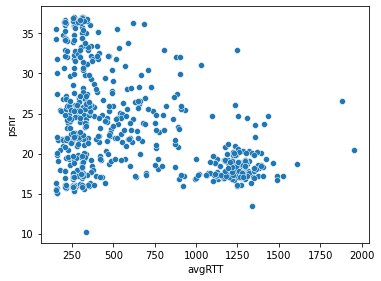

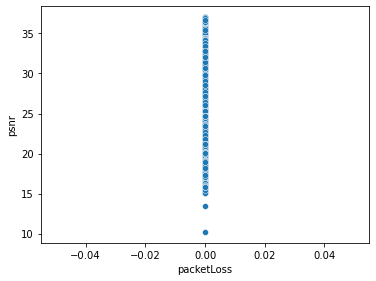

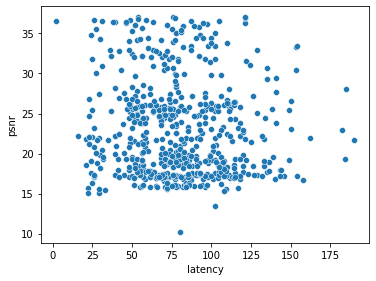

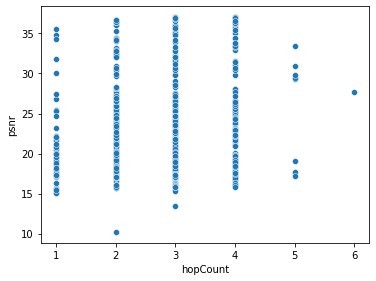

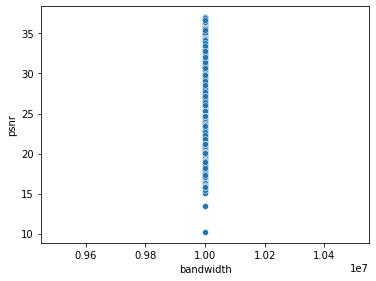

In [6]:
sayisal_veriler=["avgRTT","packetLoss","latency","hopCount","bandwidth"]
for i,deger in enumerate(sayisal_veriler):
    plt.figure(figsize=(20,20))
    ax=plt.subplot(4,3,i+1)
    sns.scatterplot(x=deger,y="psnr",data=df)
    plt.show()

In [7]:
# sns.displot(df)

In [8]:
df["mos"].value_counts()

mos
2    221
4    185
3    126
5     55
1      1
Name: count, dtype: int64

In [9]:
y=df["mos"]
x=df.drop(["mos","host","ssim_first","ssim_second","type","psnr","server","packetLoss","kaynak","kayitboyut","kayip","kayip_orani"],axis="columns")
y


0      5
1      5
2      5
3      4
4      5
      ..
588    2
589    2
590    2
591    2
592    2
Name: mos, Length: 588, dtype: int64

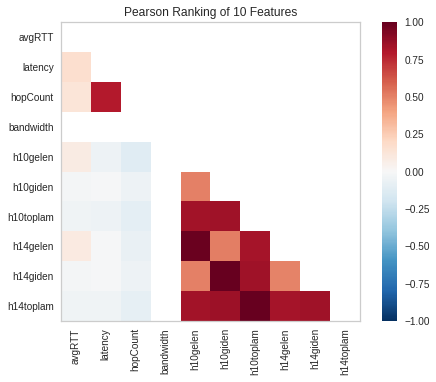

<AxesSubplot:title={'center':'Pearson Ranking of 10 Features'}>

In [10]:
from yellowbrick.features import Rank2D
visualizer=Rank2D(algorithm="pearson")
visualizer.fit(x,y)
visualizer.transform(x)
visualizer.show()

In [11]:
x.describe().T

,count,mean,std,min,25%,50%,75%,max
avgRTT,588.0,6.151730e+02,4.232686e+02,1.519770e+02,2.734425e+02,3.889160e+02,1.098511e+03,1.955956e+03
latency,588.0,7.927551e+01,3.047347e+01,2.000000e+00,5.700000e+01,7.800000e+01,9.925000e+01,1.900000e+02
hopCount,588.0,2.804422e+00,9.325721e-01,1.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00,6.000000e+00
bandwidth,588.0,1.000000e+07,0.000000e+00,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07
h10gelen,588.0,4.634943e+07,5.027084e+07,4.650000e+03,7.274784e+06,3.212345e+07,6.873616e+07,2.314258e+08
h10giden,588.0,2.208230e+07,5.928729e+07,3.491600e+04,7.084248e+05,1.559042e+06,4.848290e+06,4.799509e+08
h10toplam,588.0,3.295456e+08,5.797031e+08,4.212000e+04,1.684272e+07,1.080768e+08,3.745691e+08,5.372252e+09
h14gelen,588.0,4.653248e+07,4.974944e+07,4.902000e+03,7.271676e+06,3.215170e+07,6.872984e+07,2.314829e+08
h14giden,588.0,2.168718e+07,5.924859e+07,3.665300e+04,6.344180e+05,1.518828e+06,4.471429e+06,4.800786e+08
h14toplam,588.0,3.308962e+08,5.823559e+08,4.385100e+04,1.701816e+07,1.087544e+08,3.666178e+08,5.347883e+09


In [12]:
from sklearn.model_selection import train_test_split
XTrain,XTest,yTrain,yTest=train_test_split(x,y,test_size=0.10, random_state=42)

In [13]:
yTest.value_counts()

mos
2    24
4    21
3    10
5     4
Name: count, dtype: int64

In [14]:
from sklearn.linear_model import LinearRegression
LinModel=LinearRegression()
LinModel.fit(XTrain,yTrain)
tahmin=LinModel.predict(XTest)
from sklearn.metrics import r2_score
print(r2_score(yTest,tahmin))

0.7095407726626326


In [15]:
from sklearn.ensemble import RandomForestRegressor
for i in range(1,20,1):
    rand=RandomForestRegressor(max_depth=i,)
    rand.fit(XTrain,yTrain)
    tahminRand=rand.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,rand.predict(XTrain))} test: {r2_score(yTest,tahminRand)}")

max_depth : 1 --> score r2 : eğitim:0.5512963545736569 test: 0.5894941401831084
max_depth : 2 --> score r2 : eğitim:0.6842742980428773 test: 0.6808032150955642
max_depth : 3 --> score r2 : eğitim:0.7791719836443624 test: 0.8004320726687781
max_depth : 4 --> score r2 : eğitim:0.8361262923027639 test: 0.8155558673364136
max_depth : 5 --> score r2 : eğitim:0.8835835940354495 test: 0.8138323674586287
max_depth : 6 --> score r2 : eğitim:0.9172783748233309 test: 0.819464835196543
max_depth : 7 --> score r2 : eğitim:0.9399322172927974 test: 0.8182160367751652
max_depth : 8 --> score r2 : eğitim:0.951877707752964 test: 0.8358801492857957
max_depth : 9 --> score r2 : eğitim:0.9589648574214202 test: 0.8309206503226937
max_depth : 10 --> score r2 : eğitim:0.9657460701098025 test: 0.8349541089733674
max_depth : 11 --> score r2 : eğitim:0.9688098716803807 test: 0.8321724661969577
max_depth : 12 --> score r2 : eğitim:0.9696699781609599 test: 0.8293919249105404
max_depth : 13 --> score r2 : eğitim:0.

In [16]:
from sklearn.neighbors import KNeighborsRegressor
for i in range(1,20,1):
    KNN=KNeighborsRegressor(n_neighbors=i)
    KNN.fit(XTrain,yTrain)
    tahminKNN=KNN.predict(XTest)
    print(f"n_neigbors : {i} --> score r2 : eğitim:{r2_score(yTrain,KNN.predict(XTrain))} test: {r2_score(yTest,tahminKNN)}")

n_neigbors : 1 --> score r2 : eğitim:1.0 test: 0.47174034695019595
n_neigbors : 2 --> score r2 : eğitim:0.8331888759982733 test: 0.5501538891997761
n_neigbors : 3 --> score r2 : eğitim:0.7849197034558841 test: 0.5286016290493067
n_neigbors : 4 --> score r2 : eğitim:0.7490027806631773 test: 0.5357092893116957
n_neigbors : 5 --> score r2 : eğitim:0.7273217947334342 test: 0.6335198656966985
n_neigbors : 6 --> score r2 : eğitim:0.7111778874979016 test: 0.6409485170677113
n_neigbors : 7 --> score r2 : eğitim:0.6990372692353437 test: 0.6412011922844124
n_neigbors : 8 --> score r2 : eğitim:0.6861698472574467 test: 0.6368214885282597
n_neigbors : 9 --> score r2 : eğitim:0.6791305929283482 test: 0.640693762219597
n_neigbors : 10 --> score r2 : eğitim:0.6748699546729982 test: 0.6622439843312815
n_neigbors : 11 --> score r2 : eğitim:0.6664514741532628 test: 0.6703834396259487
n_neigbors : 12 --> score r2 : eğitim:0.6584237456381754 test: 0.6723597898402041
n_neigbors : 13 --> score r2 : eğitim:0.

In [17]:
from sklearn.tree import DecisionTreeRegressor
for i in range(1,20,1):
    DT=DecisionTreeRegressor(max_depth=i)
    DT.fit(XTrain,yTrain)
    tahminDT=DT.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,DT.predict(XTrain))} test: {r2_score(yTest,tahminDT)}")

max_depth : 1 --> score r2 : eğitim:0.5070078517124692 test: 0.4903608632295534
max_depth : 2 --> score r2 : eğitim:0.6357023720298343 test: 0.5923509143876309
max_depth : 3 --> score r2 : eğitim:0.7511120923673913 test: 0.7383000155105406
max_depth : 4 --> score r2 : eğitim:0.8080924902302178 test: 0.6868344598629345
max_depth : 5 --> score r2 : eğitim:0.8656212603344916 test: 0.6583408994966093
max_depth : 6 --> score r2 : eğitim:0.9045300345115893 test: 0.7105561519406891
max_depth : 7 --> score r2 : eğitim:0.936390745662158 test: 0.6979357041078573
max_depth : 8 --> score r2 : eğitim:0.9661556109661565 test: 0.7126812395759272
max_depth : 9 --> score r2 : eğitim:0.9873972454937832 test: 0.6537859132115187
max_depth : 10 --> score r2 : eğitim:0.9927555694000222 test: 0.6394136717431218
max_depth : 11 --> score r2 : eğitim:0.9955922823478626 test: 0.6586419023977477
max_depth : 12 --> score r2 : eğitim:0.9968778666630693 test: 0.6902149202574147
max_depth : 13 --> score r2 : eğitim:0

In [18]:
from sklearn.ensemble import GradientBoostingRegressor
for i in range(1,10,1):
    gbr=GradientBoostingRegressor(max_depth=i,loss='squared_error')
    gbr.fit(XTrain,yTrain)
    tahminGbr=gbr.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,gbr.predict(XTrain))} test: {r2_score(yTest,tahminGbr)}")

max_depth : 1 --> score r2 : eğitim:0.7636186652334859 test: 0.7502739890995747
max_depth : 2 --> score r2 : eğitim:0.8650557500926731 test: 0.8001110256892796
max_depth : 3 --> score r2 : eğitim:0.9273118929465878 test: 0.8283778265319082
max_depth : 4 --> score r2 : eğitim:0.9682410489272553 test: 0.8227518511055154
max_depth : 5 --> score r2 : eğitim:0.990303445227012 test: 0.825531266877239
max_depth : 6 --> score r2 : eğitim:0.9981490004485009 test: 0.8165417172531401
max_depth : 7 --> score r2 : eğitim:0.9998270408822385 test: 0.8081736953326404
max_depth : 8 --> score r2 : eğitim:0.9999879422981861 test: 0.8051459884762373
max_depth : 9 --> score r2 : eğitim:0.9999999314586074 test: 0.7637678097384691


In [19]:
from xgboost import XGBRegressor
xgb=XGBRegressor()
xgb.fit(XTrain,yTrain)
tahminXGB=xgb.predict(XTest)
print(r2_score(yTest,tahminXGB))

0.7728062246681846


In [20]:
from sklearn.linear_model import RANSACRegressor
ransac=RandomForestRegressor(random_state=42)
ransac.fit(XTrain,yTrain)
tahminRansac=ransac.predict(XTest)
print(f"ransac -> {r2_score(yTest,tahminRansac)}")

ransac -> 0.8353513710128707


In [29]:
from sklearn.ensemble import ExtraTreesRegressor
for i in range(1,10,1):
    exTree=ExtraTreesRegressor(max_depth=i)
    exTree.fit(XTrain,yTrain)
    tahminExTree=exTree.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,exTree.predict(XTrain))} test: {r2_score(yTest,tahminExTree)}")

    model_pkl_file=f"extraTreeRegressor{i}.pkl"

    with open(model_pkl_file,'wb') as file:
        pickle.dump(model,file)

max_depth : 1 --> score r2 : eğitim:0.46019318756456196 test: 0.4977494180342533
max_depth : 2 --> score r2 : eğitim:0.6342437144591708 test: 0.6787326687590536
max_depth : 3 --> score r2 : eğitim:0.708906104706585 test: 0.7630195037183161
max_depth : 4 --> score r2 : eğitim:0.7586882915811424 test: 0.798104973856921
max_depth : 5 --> score r2 : eğitim:0.8066897242740976 test: 0.8143317105472513
max_depth : 6 --> score r2 : eğitim:0.8543450626694719 test: 0.8276930522580755
max_depth : 7 --> score r2 : eğitim:0.8956968939163157 test: 0.8304136711263551
max_depth : 8 --> score r2 : eğitim:0.9369628966910901 test: 0.8352953857734748
max_depth : 9 --> score r2 : eğitim:0.9594800713482318 test: 0.8442595934454109


In [26]:
model=ExtraTreesRegressor(max_depth=7)
model.fit(XTrain,yTrain)
model_pkl_file="extraTreeRegressor.pkl"

with open(model_pkl_file,'wb') as file:
    pickle.dump(model,file)

In [27]:
tahminModel=model.predict(XTest)
print(f"max_depth : {7} --> score r2 : eğitim:{r2_score(yTrain,exTree.predict(XTrain))} test: {r2_score(yTest,tahminModel)}")

max_depth : 9 --> score r2 : eğitim:0.9621761832591909 test: 0.8261250365670159


In [30]:
tahminModel

array([2.01739659, 2.0012492 , 2.49251701, 3.20861354, 3.78041013,
       3.57785471, 2.07904362, 3.35094331, 4.47123824, 3.87430315,
       4.02565654, 3.33928884, 3.97134777, 2.182441  , 2.05562965,
       2.44551569, 4.07616865, 2.09218329, 4.31477583, 2.25724273,
       3.14888233, 3.59662965, 3.86699021, 2.02299076, 2.31829595,
       3.56743105, 3.57841984, 2.11469036, 2.00043723, 3.91380324,
       2.89949053, 2.99425313, 2.04373882, 2.00446965, 3.46232976,
       2.00043723, 2.15948487, 3.43608468, 2.00297931, 2.23666145,
       2.06498223, 3.31493322, 4.10583084, 3.55288056, 3.88345205,
       3.93601186, 3.82410731, 2.23010196, 2.31199725, 3.86231762,
       4.43086643, 2.66756034, 4.18709621, 2.04791983, 2.00170374,
       2.93629744, 3.98111362, 3.85382499, 2.17651944])

In [22]:
tahminGbr

array([2.00005305, 2.00004194, 2.000069  , 2.99217945, 3.92989164,
       3.63271253, 2.00004554, 3.34310607, 3.87907183, 3.93495963,
       3.86075751, 3.99903705, 3.999522  , 2.00002238, 2.00004552,
       1.99817866, 4.22622588, 2.00004479, 3.86114631, 2.00014202,
       2.78804528, 3.35369772, 4.00353725, 2.00004552, 2.00048913,
       3.07467731, 3.50821419, 2.00004579, 2.00004194, 4.03963844,
       2.99980735, 3.95384645, 2.00004579, 2.00004196, 3.99859104,
       2.00004552, 2.00006721, 3.09827549, 2.00004552, 2.13135353,
       2.000041  , 3.15477885, 4.09716166, 3.99900706, 3.95952435,
       3.96007127, 3.82177817, 2.00002901, 2.00020548, 3.97671998,
       4.66748364, 2.9519213 , 3.99712628, 2.00004554, 2.00004194,
       2.99998112, 3.98401837, 3.59781216, 2.07983832])

In [23]:
yTest

525    2
286    2
517    2
333    3
211    4
90     4
301    2
181    4
549    4
137    4
550    4
70     4
397    4
236    2
425    2
155    3
210    4
373    2
506    5
182    3
282    3
229    4
2      5
563    2
200    2
63     4
55     4
588    2
288    2
29     4
477    2
233    2
589    2
251    2
82     4
322    2
283    2
176    3
456    2
555    2
250    2
212    3
177    5
10     4
429    4
529    4
6      4
492    2
351    2
279    3
145    5
554    3
72     4
454    2
252    2
426    3
101    4
86     4
382    3
Name: mos, dtype: int64

In [24]:
yTrain

318    2
76     4
532    3
573    4
30     4
      ..
71     3
106    4
272    2
438    2
102    4
Name: mos, Length: 529, dtype: int64

In [25]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
XTrain[sayisal_veriler]=scaler.fit_transform(XTrain[sayisal_veriler])
XTest[sayisal_veriler]=scaler.transform(XTest[sayisal_veriler])

KeyError: "['packetLoss'] not in index"

In [ ]:
from sklearn.linear_model import LinearRegression
LogModel=LinearRegression()
LogModel.fit(XTrain,yTrain)
tahmin=LogModel.predict(XTest)
from sklearn.metrics import r2_score
print(r2_score(yTest,tahmin))

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
for i in range(1,20,1):
    KNN=KNeighborsRegressor(n_neighbors=i)
    KNN.fit(XTrain,yTrain)
    tahminKNN=KNN.predict(XTest)
    print(f"n_neigbors : {i} --> score r2 : eğitim:{r2_score(yTrain,KNN.predict(XTrain))} test: {r2_score(yTest,tahminKNN)}")

In [ ]:
from sklearn.ensemble import RandomForestRegressor
for i in range(1,20,1):
    rand=RandomForestRegressor(max_depth=i,bootstrap=True,criterion="friedman_mse",max_features='log2',max_leaf_nodes=None,n_estimators=100,n_jobs=1,random_state=42)
    rand.fit(XTrain,yTrain)
    tahminRand=rand.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,rand.predict(XTrain))} test: {r2_score(yTest,tahminRand)}")

In [ ]:
from sklearn.tree import DecisionTreeRegressor
for i in range(1,20,1):
    DT=DecisionTreeRegressor(max_depth=i)
    DT.fit(XTrain,yTrain)
    tahminDT=DT.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,DT.predict(XTrain))} test: {r2_score(yTest,tahminDT)}")

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
for i in range(1,10,1):
    gbr=GradientBoostingRegressor(max_depth=i,loss='squared_error')
    gbr.fit(XTrain,yTrain)
    tahminGbr=gbr.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,gbr.predict(XTrain))} test: {r2_score(yTest,tahminGbr)}")